In [1]:
pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.5 MB ? eta -:--:--
    --------------------------------------- 0.5/39.5 MB 1.6 MB/s eta 0:00:25
    --------------------------------------- 0.8/39.5 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.3/39.5 MB 1.5 MB/s eta 0:00:25
   - -------------------------------------- 1.6/39.5 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.8/39.5 MB 1.5 MB/s eta 0:00:26
   -- ------------------------------------- 2.1/39.5 MB 1.5 MB/s eta 0:00:25
   -- ------------------------------------- 2.4/39.5 MB 1.5 MB/s eta 0:00:25
   -- ------------------------------------- 2.6/39.5 MB 1.5 MB/s eta 0:00:25
   --- ------------------------------------ 3.1/39.5 MB 1.5 MB/s eta 0:00:25
   --- ------------------------------------ 3.4/39.5 MB 1.5 MB/s eta 0:00:25
   --- -----

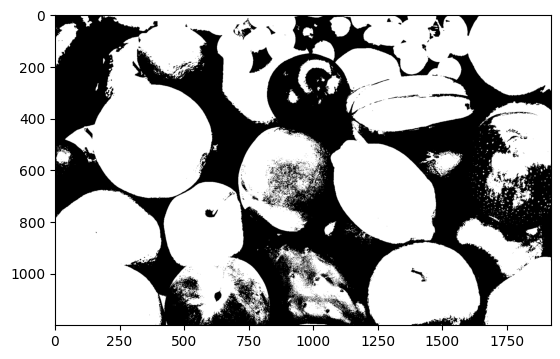

In [6]:
# Phương pháp ostu
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

data = Image.open('./fruit.jpg').convert('L')
a = np.asarray(data)

thres = threshold_otsu(a)
b = a > thres
b = Image.fromarray(b)

plt.imshow(b)
plt.show()

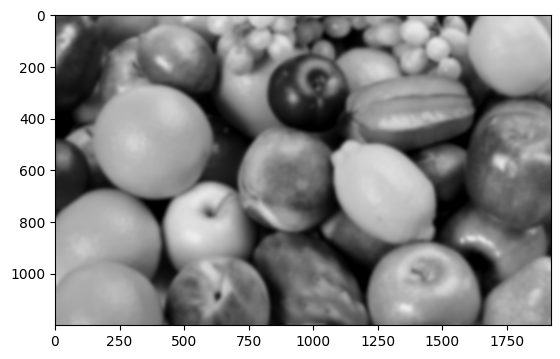

In [8]:
# Phương pháp Adaptive Thresholding
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = Image.open('./fruit.jpg').convert('L')
a = np.asarray(data)

b = threshold_local(a, 39, offset=10)
b = Image.fromarray(b)

plt.imshow(b)
plt.show()

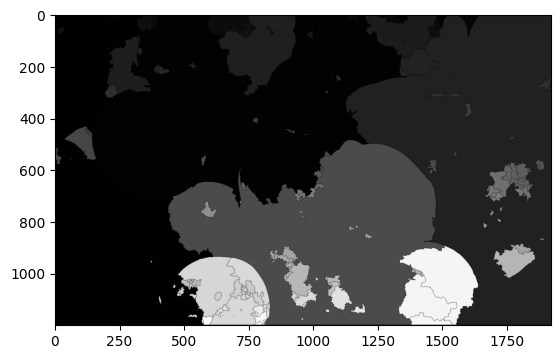

In [10]:
# Phân vùng theo vùng
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = cv2.imread('./fruit.jpg')
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
b2 = cv2.erode(b1, None, iterations=2)
dist_trans = cv2.distanceTransform(b2, 2, 3)
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)
labelled, ncc = label(dt)
labelled = labelled.astype(np.int32)
cv2.watershed(data, labelled)
b = Image.fromarray(labelled)

plt.imshow(b)
plt.show()

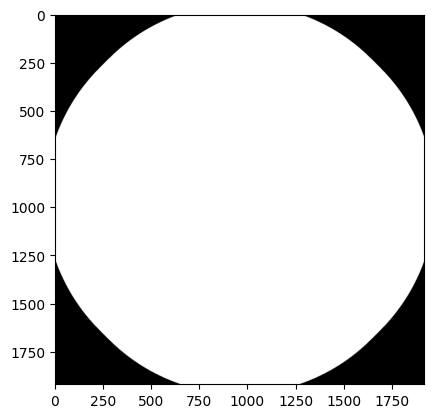

In [31]:
# binary_dilation
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = Image.open('./circle.jpg').convert('L')
b = nd.binary_dilation(data, iterations=50)

c = Image.fromarray(b)
# c.show()
plt.imshow(c)
plt.show()

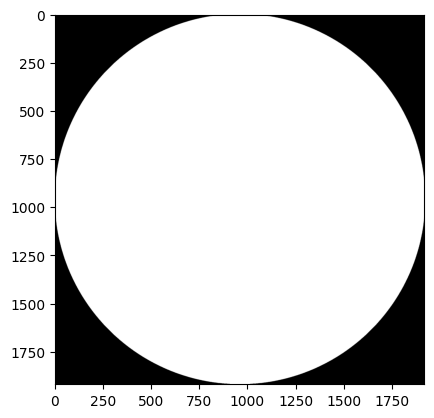

In [32]:
# binary_opening
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = Image.open('./circle.jpg').convert('L')
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b =nd.binary_opening(data, structure=s, iterations=25)
c = Image.fromarray(b)
# c.show()
plt.imshow(c)
plt.show()

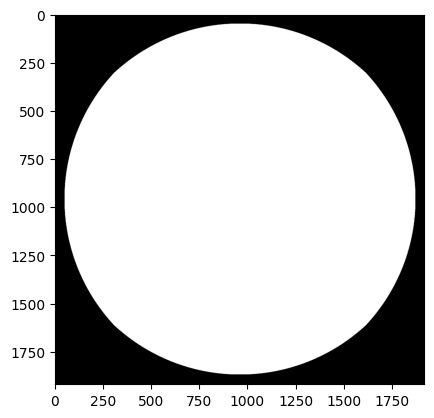

In [33]:
# binary_erosion
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = Image.open('./circle.jpg').convert('L')
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b =nd.binary_erosion(data, structure=s, iterations=50)
c = Image.fromarray(b)
# c.show()
plt.imshow(c)
plt.show()

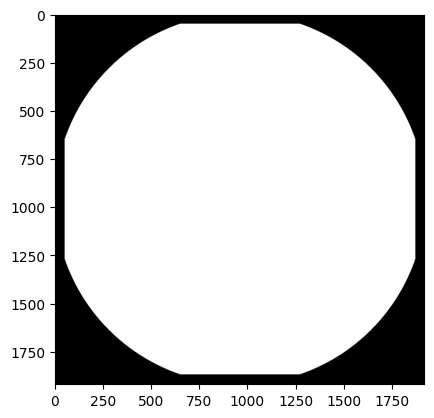

In [34]:
# binary_closing
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_local

data = Image.open('./circle.jpg').convert('L')
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b =nd.binary_closing(data, structure=s, iterations=50)
c = Image.fromarray(b)
# c.show()
plt.imshow(c)
plt.show()